In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, roc_auc_score,
                             classification_report)

df = pd.read_csv('../Dataset/final_data.csv')
X = df.drop('GradeClass', axis=1)
y = df['GradeClass']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

lr  = joblib.load('../Model/logistic_regression.pkl')
rf  = joblib.load('../Model/random_forest.pkl')
xgb = joblib.load('../Model/xgboost.pkl')

lr_pred  = lr.predict(X_test)
rf_pred  = rf.predict(X_test)
xgb_pred = xgb.predict(X_test)

print("✅ Models & data loaded")

✅ Models & data loaded


In [6]:
def get_metrics(name, y_test, y_pred, model):
    return {
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred, average='weighted'), 4),
        'Recall'   : round(recall_score(y_test, y_pred, average='weighted'), 4),
        'F1 Score' : round(f1_score(y_test, y_pred, average='weighted'), 4),
        'ROC-AUC'  : round(roc_auc_score(y_test,
                           model.predict_proba(X_test),
                           multi_class='ovr', average='weighted'), 4)
    }

metrics = pd.DataFrame([
    get_metrics('Logistic Regression', y_test, lr_pred, lr),
    get_metrics('Random Forest',       y_test, rf_pred, rf),
    get_metrics('XGBoost',             y_test, xgb_pred, xgb)
])

print(metrics.to_string(index=False))
metrics.to_csv('../Documentation/model_metrics.csv', index=False)
print("\n✅ Metrics saved")

              Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
Logistic Regression    0.7370     0.7168  0.7370    0.7157   0.9147
      Random Forest    0.9186     0.9205  0.9186    0.9143   0.9464
            XGBoost    0.9144     0.9161  0.9144    0.9107   0.9377

✅ Metrics saved


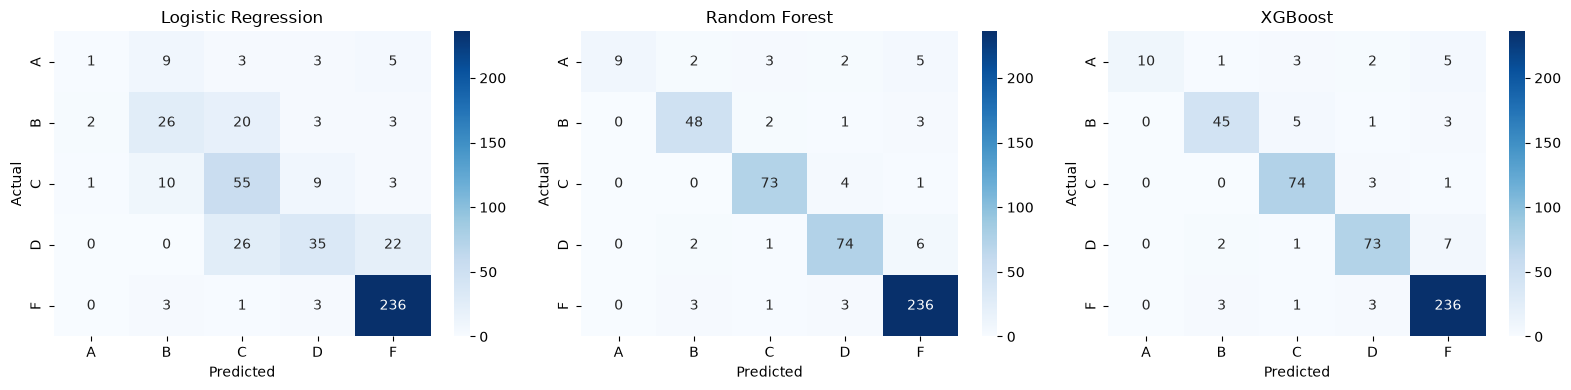

✅ Confusion matrices saved


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
models = [('Logistic Regression', lr_pred),
          ('Random Forest',       rf_pred),
          ('XGBoost',             xgb_pred)]

grade_labels = ['A', 'B', 'C', 'D', 'F']

for ax, (name, pred) in zip(axes, models):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=grade_labels, yticklabels=grade_labels)
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('../Documentation/confusion_matrices.png')
plt.show()
print("✅ Confusion matrices saved")

In [8]:
best = metrics.loc[metrics['Accuracy'].idxmax()]
print("🏆 Best Model  :", best['Model'])
print("   Accuracy    :", best['Accuracy'])
print("   Precision   :", best['Precision'])
print("   Recall      :", best['Recall'])
print("   F1 Score    :", best['F1 Score'])
print("   ROC-AUC     :", best['ROC-AUC'])

🏆 Best Model  : Random Forest
   Accuracy    : 0.9186
   Precision   : 0.9205
   Recall      : 0.9186
   F1 Score    : 0.9143
   ROC-AUC     : 0.9464
